<a href="https://colab.research.google.com/github/kumisganteng/Telco-Customer-Churn-Analysis/blob/tahap_eda/Improving_Customer_Retention_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. DATA INGESTION

## 1.1 Pemuatan Data





In [ ]:
import pandas as pd

churn_file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
churn_data = pd.read_csv(churn_file_path)



##1.2 Inspeksi Data

In [ ]:
churn_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
churn_data.shape

(7043, 21)

## 1.3 Descriptive Statistics

In [ ]:
churn_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# 2. DATA CLEANING

## 2.1 Mengecek Berapa Banyak Isi Sel Yang Null


In [ ]:
churn_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


#### Mengubah sel yg kosong dengan NaN
####Melihat dari hasil pengecekan data kosong, ternyata semua atributnya tidak punya data kosong, maka dari itu kita ubah segala bentuk kekosongan sel menjadi NaN/Null/NA

In [ ]:
#Mengeubah kekosongan menjadi NA
churn_data = churn_data.replace(r'^\s*$', pd.NA, regex=True)

In [ ]:
churn_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


##2.2 Menghapus Data Kosong
####TotalCharges ternyata ada 11 sel kosong, karena sangat sedikit dari jumlah keseluruhan, maka dihapus saja

In [ ]:
#Menghapus data yg kosong
churn_data = churn_data.dropna()

In [ ]:
churn_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


###2.3 Menghapus kolom yang tidak kepakai di data analisis
#### customerID tidak memiliki pola(noice),mencegah overfitting, dan bisa mengganggu visualisasi data

In [ ]:
#Menghapus customerID
churn_data = churn_data.drop(columns = ['customerID'])

In [ ]:
# cek kolom setelah hapus customerID
churn_data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

###2.4 Menghapus Duplikasi Data

In [ ]:
#Mengecek apakah ada baris yg redundan
churn_data.duplicated().sum()

np.int64(22)

####Ditemukan 22 duplicated records yang kemudian dihapus untuk menghindari bias pada model.

In [ ]:
#Menghapus baris yg redundan
churn_data = churn_data.drop_duplicates()

###2.5 Validasi Tipe Data

####Mengecek apakah terdapat tipe data yang tidak sesuai dengan yang seharusnya, seperti pada contoh TotalCharges harus memiliki tipe data float, maka diubah

In [ ]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   object 
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   object 
 3   Dependents        7010 non-null   object 
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   object 
 6   MultipleLines     7010 non-null   object 
 7   InternetService   7010 non-null   object 
 8   OnlineSecurity    7010 non-null   object 
 9   OnlineBackup      7010 non-null   object 
 10  DeviceProtection  7010 non-null   object 
 11  TechSupport       7010 non-null   object 
 12  StreamingTV       7010 non-null   object 
 13  StreamingMovies   7010 non-null   object 
 14  Contract          7010 non-null   object 
 15  PaperlessBilling  7010 non-null   object 
 16  PaymentMethod     7010 non-null   object 
 17  

In [ ]:
#Mengubah tipe data pada TotalCharges menjadi float
churn_data['TotalCharges'] = pd.to_numeric(churn_data['TotalCharges'], errors = 'coerce')

In [ ]:
#Setelah itu Mengecek total sel yang isinya null
churn_data['TotalCharges'].isnull().sum()

np.int64(0)

###2.6 Standarisasi Nilai Kategorikal

####Mengecek unique tiap kolom kategori
####Jika terdapat isi sel yang berbagai macam seperti 'NO', 'No', 'no',' no', itu berarti terdapat 4 data yang unik, sehingga harus di jadikan 1 bentuk yg seragam sesuai kesepakatan seperti 'No' agar semua yg no memakai 'No'

In [ ]:
for col in churn_data.select_dtypes(include = 'object').columns:
  print(col, churn_data[col].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn ['No' 'Yes']


####Mengubah isi sel seperti 'No internet service' menjadi No, begitupun untuk kolom yang lainnya

In [ ]:
cols_fix = [
    'MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]

for col in cols_fix:
    churn_data[col] = churn_data[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })

In [ ]:
# Mengecek kembali apakah sidah ada perubahan pada isi sel yang tadi sudah di seragamkan kategorisasinya
for col in churn_data.select_dtypes(include = 'object').columns:
  print(col, churn_data[col].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes']
OnlineBackup ['Yes' 'No']
DeviceProtection ['No' 'Yes']
TechSupport ['No' 'Yes']
StreamingTV ['No' 'Yes']
StreamingMovies ['No' 'Yes']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn ['No' 'Yes']


##2.7 Validasi Range Numerik

####Mengubah agar Churn tidak bertipe data object lagi tapi agar menjadi tipe data yang bisa dioperasikan

In [ ]:
#Mengubah isi data pada Churn menjadi 1 (Yes), dan 0(No)
churn_data['Churn']=churn_data['Churn'].map({'Yes' : 1, 'No' : 0})

In [ ]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   object 
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   object 
 3   Dependents        7010 non-null   object 
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   object 
 6   MultipleLines     7010 non-null   object 
 7   InternetService   7010 non-null   object 
 8   OnlineSecurity    7010 non-null   object 
 9   OnlineBackup      7010 non-null   object 
 10  DeviceProtection  7010 non-null   object 
 11  TechSupport       7010 non-null   object 
 12  StreamingTV       7010 non-null   object 
 13  StreamingMovies   7010 non-null   object 
 14  Contract          7010 non-null   object 
 15  PaperlessBilling  7010 non-null   object 
 16  PaymentMethod     7010 non-null   object 
 17  

###Mengecek apakah Tenure ada yang kurang dari 0

In [ ]:
churn_data[churn_data['tenure'] <= 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [ ]:
# Memastikan secara langsung jumlah tenure ada yg lebih kecil dari 0 atau tidak
(churn_data['tenure'] <= 0).sum()

np.int64(0)

####Mengecek apakah MonthlyCharges ada yg lebih kecil dari 0

In [ ]:
churn_data[churn_data['MonthlyCharges'] < 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


####Sekarang cek juga untuk TotalCharges

In [ ]:
churn_data[churn_data['TotalCharges'] <= 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


###Mengecek Outlier Pakai IQR

####Hitung Q1 dan Q2

In [ ]:
Q1 = churn_data['MonthlyCharges'].quantile(0.25)
Q3 = churn_data['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1

####Menentukan Batas Outlier

In [ ]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#### Mengambil Data Outlier

In [ ]:
outliers = churn_data[
    (churn_data['MonthlyCharges'] < lower_bound) |
    (churn_data['MonthlyCharges'] > upper_bound)
]

outliers.shape

(0, 20)

####Mengecek deskripsi MonthlyCharges

In [ ]:
churn_data['MonthlyCharges'].describe()

,MonthlyCharges
count,7010.000000
mean,64.888666
std,30.064769
min,18.250000
25%,35.750000
50%,70.400000
75%,89.900000
max,118.750000


#### Kesimpulannya adalah MonthlyCharges Normal

####Mengecek konsistensi logika layanan
####Kalau PhoneService = 'No'
####maka MultipleLines tidak boleh 'Yes'

In [ ]:
phone_conflict = churn_data[
    (churn_data['PhoneService'] == 'No') &
    (churn_data['MultipleLines'] == 'Yes')
]

phone_conflict.shape

(0, 20)

In [ ]:
internet_conflict = churn_data[
    (churn_data['InternetService'] == 'No') &
    (
        (churn_data['OnlineSecurity'] == 'Yes') |
        (churn_data['OnlineBackup'] == 'Yes') |
        (churn_data['DeviceProtection'] == 'Yes') |
        (churn_data['TechSupport'] == 'Yes') |
        (churn_data['StreamingTV'] == 'Yes') |
        (churn_data['StreamingMovies'] == 'Yes')
    )
]

In [ ]:
internet_conflict.shape

(0, 20)

#### Logika yang di cek sudah benar dan tidak ada yang salah

#3. EXPLORATORY DATA ANALYSIS

##3.1 Univariate Analysis

####Distribusi Target

In [ ]:
churn_data['Churn'].value_counts()

,count
Churn,
0,5153
1,1857


####Visualisasi

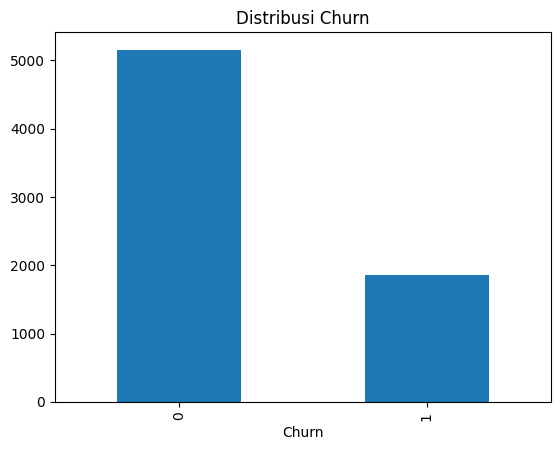

In [ ]:
import matplotlib.pyplot as plt

churn_data['Churn'].value_counts().plot(kind='bar')
plt.title('Distribusi Churn')
plt.show()

###Distribusi Vitur Numerik = 1.tenure 2. MonthlyCharges 3. Total Charges


#### DVN 'tenure

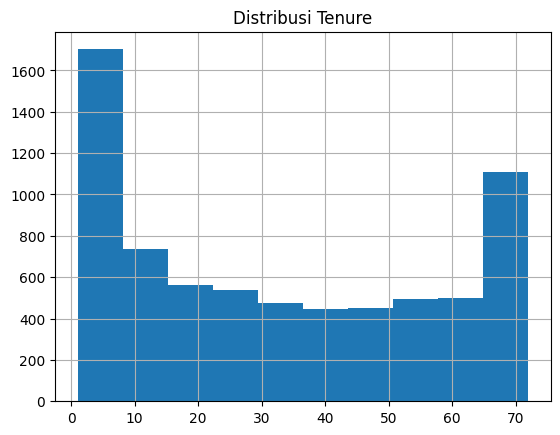

In [ ]:
#untuk tenure
churn_data['tenure'].hist()
plt.title('Distribusi Tenure')
plt.show()

####DVN 'MonthlyCharges'

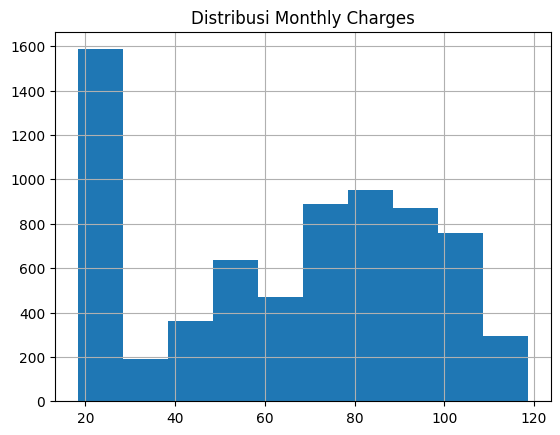

In [ ]:
#untuk MonthlyCharges
churn_data['MonthlyCharges'].hist()
plt.title('Distribusi Monthly Charges')
plt.show()

####DVN 'TotalCharges'

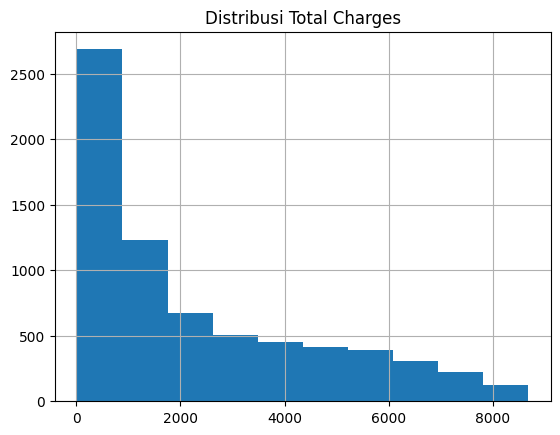

In [ ]:
#untuk TotalCharges
churn_data['TotalCharges'].hist()
plt.title('Distribusi Total Charges')
plt.show()

###Distribusi Fitur Kategorikal

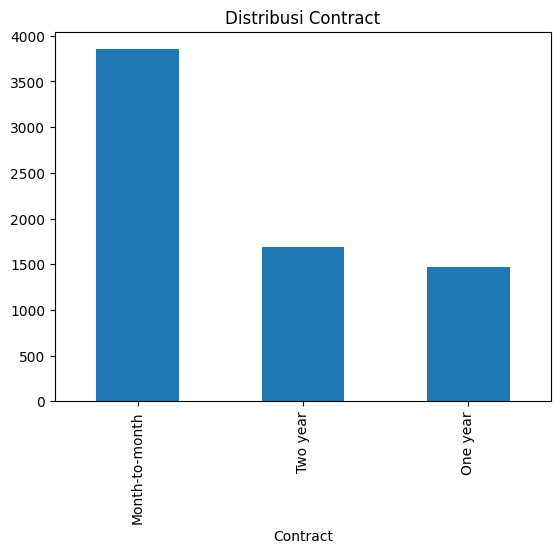

In [ ]:
churn_data['Contract'].value_counts().plot(kind='bar')
plt.title('Distribusi Contract')
plt.show()

##3.2 Bivariate Analysis

###Menganalisis Hubungan Churn dengan Fitur Kategorikal

---



####Contract vs Churn



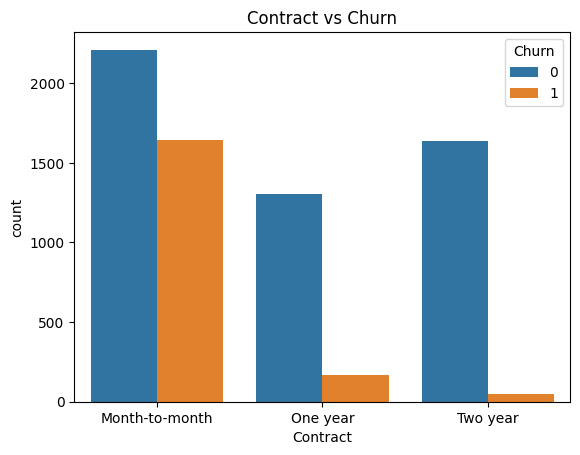

In [ ]:
###Hubungan Contract dengan Churn
import seaborn as sns

sns.countplot(x='Contract', hue='Churn', data=churn_data)
plt.title('Contract vs Churn')
plt.show()

####TechSupport vs Churn

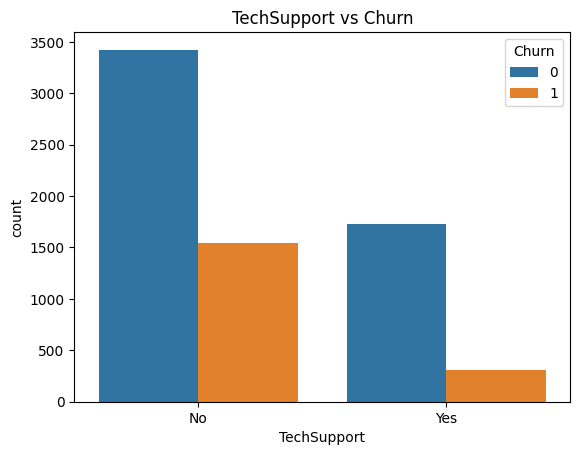

In [ ]:
sns.countplot(x='TechSupport', hue='Churn', data=churn_data)
plt.title('TechSupport vs Churn')
plt.show()

####OnlineSecurity vs Churn

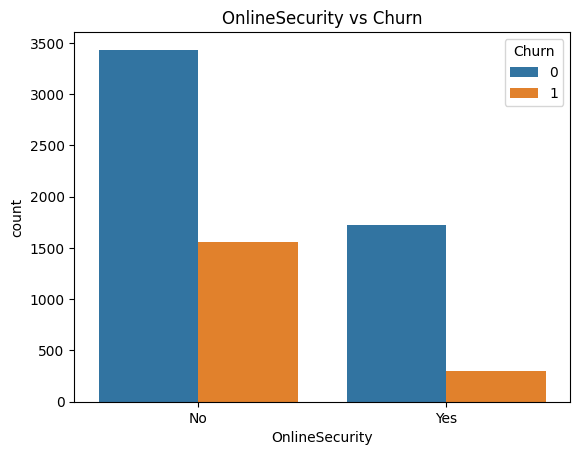

In [ ]:
sns.countplot(x='OnlineSecurity', hue='Churn', data=churn_data)
plt.title('OnlineSecurity vs Churn')
plt.show()

####InternetService vs Churn

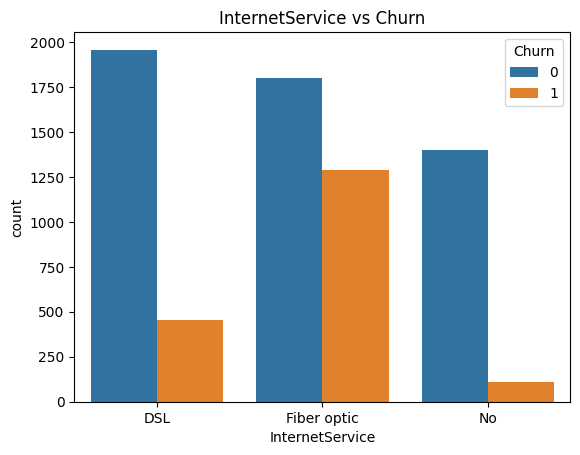

In [ ]:
sns.countplot(x='InternetService', hue='Churn', data=churn_data)
plt.title('InternetService vs Churn')
plt.show()

####PaymentMethod vs Churn

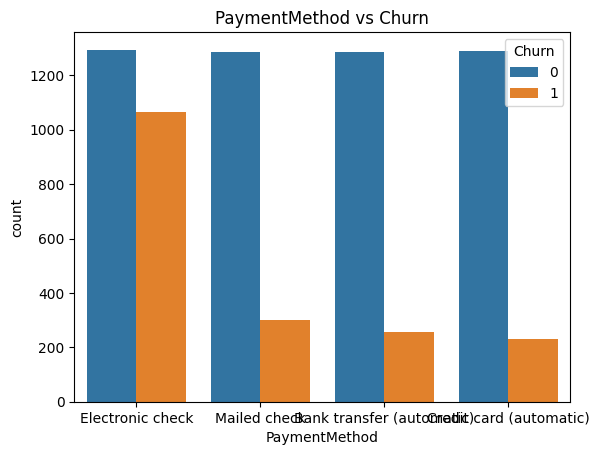

In [ ]:
sns.countplot(x='PaymentMethod', hue='Churn', data=churn_data)
plt.title('PaymentMethod vs Churn')
plt.show()

####tenure vs Churn (boxplot)

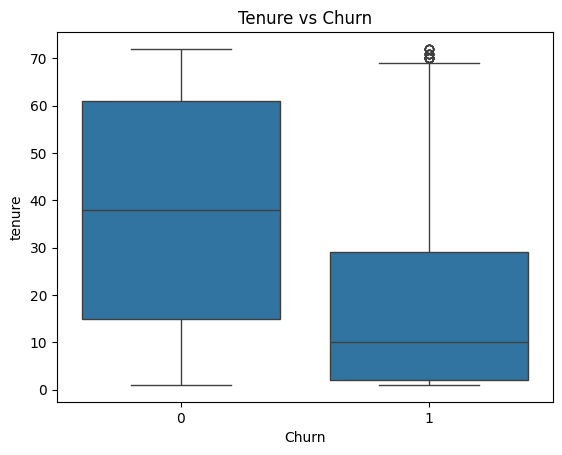

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=churn_data)
plt.title('Tenure vs Churn')
plt.show()

###Churn vs Numerik

####tenure vs Churn (boxplot)

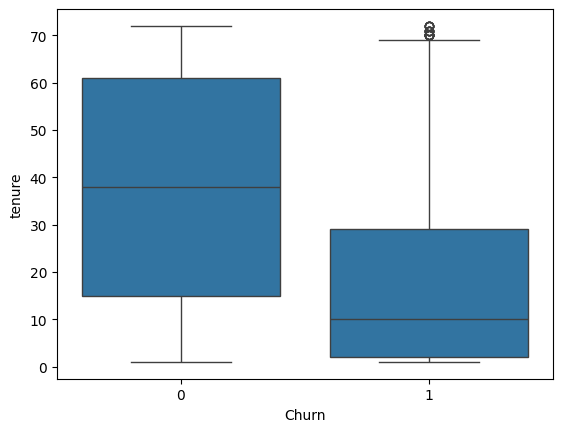

In [61]:
sns.boxplot(x='Churn', y='tenure', data=churn_data)
plt.show()

MonthlyCharges vs Churn (boxplot)

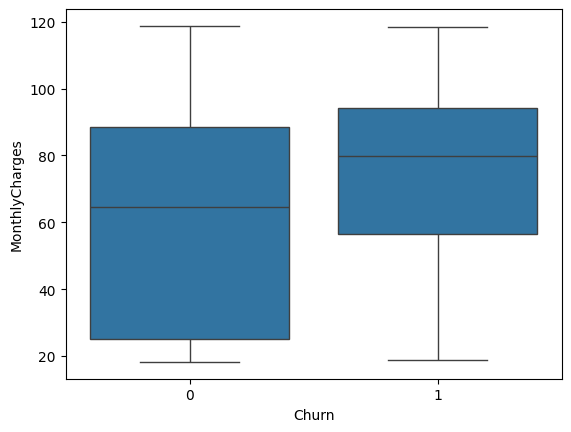

In [62]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=churn_data)
plt.show()

####TotalCharges vs Churn(boxplot)

In [ ]:
sns.boxplot(x='Churn', y='TotalCharges', data=churn_data)
plt.show()